# Choice decoding: cross-partition generalization

Complementary to `20260617_visualize_choice_by_belief_dim.ipynb`.

Results live in `/data/patrick_res/choice_belief_dim_cross_partition`: choice decoders trained on one belief-dim partition and evaluated on a *different* (non-overlapping) partition, named `{train}_to_{test}`.

For each belief-dim partition (the *tested-on* partition) we make one subplot overlaying the decoders trained on each of the other partitions. The line whose colour matches the panel's own partition is the within-partition decoder (read from `/data/patrick_res/choice_belief_dim`), included as a reference baseline.

Note: the cross-partition runs were only done for All Regions (no region split), so there is a single figure per trial event.

In [1]:
import sys
sys.path.insert(0, '/src/wcst_decode')

import os
import argparse
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.visualization_utils as visualization_utils
import scripts.pseudo_decoding.belief_partitions.belief_partitions_io as belief_partitions_io
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import (
    BeliefPartitionConfigs,
    CrossPartitionConfigs,
)
from constants.behavioral_constants import FEATURES
from constants.decoding_constants import get_trial_interval

plt.rcParams.update({'font.size': 16})

### Setup, helper functions

In [2]:
CROSS_OUTPUT_PATH = "/data/patrick_res/choice_belief_dim_cross_partition"
WITHIN_OUTPUT_PATH = "/data/patrick_res/choice_belief_dim"
SIG_UNIT_LEVEL = "choice_99th_window_filter_drift"
PARTITIONS = ["Low", "In X Dim", "Not in X Dim"]
NUM_SHUFFLES = 10

# Per-event x-axis ticks / event markers / labels.
EVENT_CONFIG = {
    "FeedbackOnsetLong": {
        "ticks": [-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5],
        "vlines": [-0.8, 0.0],
        "xlabel": "Time to feedback (s)",
    },
    "StimOnset": {
        "ticks": [-1.0, -0.5, 0.0, 0.5, 1.0],
        "vlines": [0.0],
        "xlabel": "Time to stim onset (s)",
    },
}

# Lines are coloured by the partition the decoder was TRAINED on,
# matching the palette used in the within-partition notebook.
PARTITION_COLORS = {
    "Low":          "#1f77b4",
    "In X Dim":     "#ff7f0e",
    "Not in X Dim": "#2ca02c",
}
PARTITION_SHUFFLE_COLORS = {
    "Low":          "#aec7e8",
    "In X Dim":     "#ffbb78",
    "Not in X Dim": "#98df8a",
}

In [3]:
def load_cross_partition_df(train_partition, test_partition, trial_event, num_shuffles=NUM_SHUFFLES):
    """Cross-partition results: decoder trained on `train_partition`, evaluated on `test_partition`.

    Returns a long df with columns Time, run, Accuracy, mode (choice / choice_shuffle),
    feat, train_partition, test_partition.
    """
    args = argparse.Namespace(**CrossPartitionConfigs()._asdict())
    args.mode = "choice"
    args.subject = "both"
    args.trial_event = trial_event
    args.sig_unit_level = SIG_UNIT_LEVEL
    args.base_output_path = CROSS_OUTPUT_PATH
    args.train_partition = train_partition
    args.test_partition = test_partition
    args.trial_interval = get_trial_interval(trial_event)

    def load_feats(shuffle_idx):
        is_shuffle = shuffle_idx is not None
        args.shuffle_idx = shuffle_idx
        dir = belief_partitions_io.get_cross_partition_dir_name(args, make_dir=False)
        dfs = []
        for feat in FEATURES:
            args.feat = feat
            file_name = belief_partitions_io.get_cross_partition_file_name(args)
            path = os.path.join(dir, f"{file_name}_accs.npy")
            try:
                acc = np.load(path)
            except FileNotFoundError:
                if is_shuffle:
                    continue
                raise
            df = belief_partitions_io.transform_np_acc_to_df(acc, args)
            df["feat"] = feat
            df["mode"] = "choice_shuffle" if is_shuffle else "choice"
            dfs.append(df)
        return pd.concat(dfs) if dfs else None

    res = [load_feats(None)]
    for shuffle_idx in range(num_shuffles):
        shuf = load_feats(shuffle_idx)
        if shuf is not None:
            res.append(shuf)
    df = pd.concat(res)
    df["train_partition"] = train_partition
    df["test_partition"] = test_partition
    return df


def load_within_partition_df(partition, trial_event, num_shuffles=NUM_SHUFFLES):
    """Within-partition baseline: decoder trained and tested on the same partition."""
    args = argparse.Namespace(**BeliefPartitionConfigs()._asdict())
    args.mode = "choice"
    args.subject = "both"
    args.trial_event = trial_event
    args.sig_unit_level = SIG_UNIT_LEVEL
    args.base_output_path = WITHIN_OUTPUT_PATH
    args.beh_filters = {"BeliefDimPartition": partition}
    df = belief_partitions_io.read_results(args, FEATURES, num_shuffles=num_shuffles)
    df["train_partition"] = partition
    df["test_partition"] = partition
    return df


def load_all_results(trial_event, include_within=True):
    """Concatenate every (train, test) combination for a trial event.

    The within-partition (train == test) rows come from the within-partition run
    and act as the generalization baseline for each tested-on partition.
    """
    dfs = []
    for test_partition in PARTITIONS:
        for train_partition in PARTITIONS:
            if train_partition == test_partition:
                if include_within:
                    dfs.append(load_within_partition_df(test_partition, trial_event))
            else:
                dfs.append(load_cross_partition_df(train_partition, test_partition, trial_event))
    return pd.concat(dfs, ignore_index=True)

In [4]:
def plot_cross_partition_by_test(all_df, trial_event, label=""):
    """One subplot per tested-on partition; each line is a decoder trained on some partition."""
    cfg = EVENT_CONFIG[trial_event]
    is_shuffle = all_df["mode"].str.contains("shuffle")
    real, shuffle = all_df[~is_shuffle], all_df[is_shuffle]

    fig, axs = plt.subplots(1, len(PARTITIONS), figsize=(18, 4), sharey=True)
    for i, (ax, test_partition) in enumerate(zip(axs, PARTITIONS)):
        real_t = real[real.test_partition == test_partition]
        shuffle_t = shuffle[shuffle.test_partition == test_partition]
        # train partitions present for this panel, in a consistent order
        train_order = [p for p in PARTITIONS if p in real_t.train_partition.unique()]

        sns.lineplot(
            shuffle_t, x="Time", y="Accuracy",
            hue="train_partition", hue_order=train_order,
            palette=PARTITION_SHUFFLE_COLORS,
            linewidth=2, linestyle="dashed",
            errorbar="se", ax=ax, legend=False,
        )
        sns.lineplot(
            real_t, x="Time", y="Accuracy",
            hue="train_partition", hue_order=train_order,
            palette=PARTITION_COLORS,
            linewidth=3, errorbar="se", ax=ax,
        )
        ax.axhline(y=0.5, linestyle="dotted", color="black")
        for v in cfg["vlines"]:
            ax.axvline(v, color="grey", linestyle="dotted", linewidth=3)
        ax.set_title(f"Tested on: {test_partition}")
        ax.set_xlabel(cfg["xlabel"])
        ax.set_xticks(cfg["ticks"])
        ax.set_xticklabels(cfg["ticks"])
        ax.set_ylim([0.44, 1.0])
        if i == 0:
            for line in ax.legend(title="Trained on").get_lines():
                line.set_linewidth(6)
            ax.set_ylabel("Accuracy")
        else:
            ax.get_legend().remove()
            ax.set_ylabel("")
    visualization_utils.format_plot(list(axs))
    title = "Choice decoding cross-partition generalization"
    if label:
        title += f" \u2014 {label}"
    fig.suptitle(title, y=1.05)
    fig.tight_layout()
    return fig

### Plot cross-partition generalization, per tested-on partition

In each panel, the solid line whose colour matches the panel's own partition is the within-partition decoder (trained + tested on that partition); the other solid lines are decoders trained on a different partition and evaluated here. Dashed lines are the shuffle baselines.

=== FeedbackOnsetLong ===


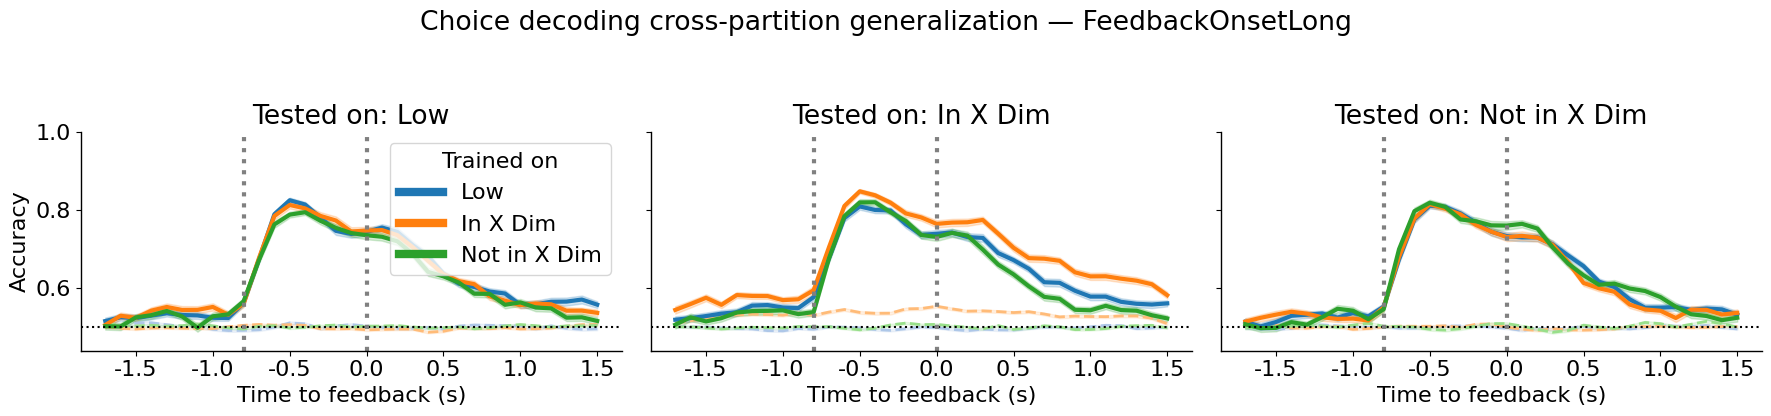

=== StimOnset ===


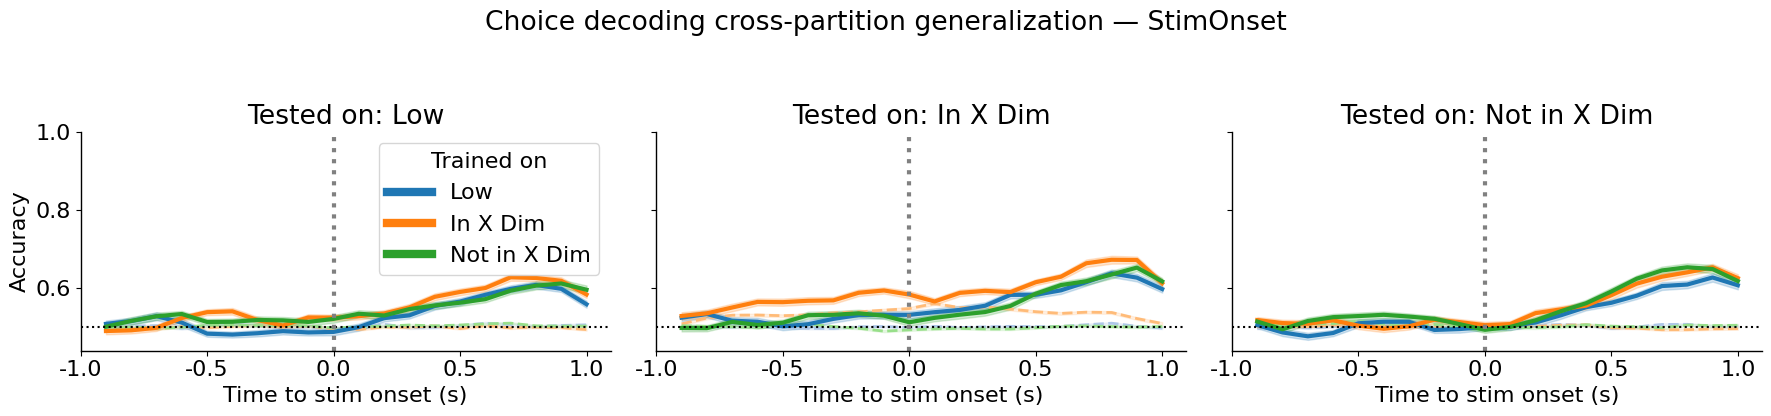

In [5]:
for trial_event in ["FeedbackOnsetLong", "StimOnset"]:
    print(f"=== {trial_event} ===")
    all_df = load_all_results(trial_event, include_within=True)
    plot_cross_partition_by_test(all_df, trial_event, label=trial_event)
    plt.show()